# EchoMind — Multimodal Fusion v5 SAFE FINAL

Versão corrigida para os testes reais:
- Qwen Advanced_V2 mantido, com pós-processamento semântico conservador;
- prosódia v4 mantida, mas limitada por guarda anti-colapso;
- late fusion adaptativa segura, mais textual quando há conflito;
- output final continua a guardar distribuições, ranking, pesos, incerteza e motivos da fusão.

In [1]:
# ============================================================
# 1. Instalação de dependências
# ============================================================
# Em ambiente novo, descomenta conforme necessário.
# A primeira execução com Whisper/WavLM pode precisar de internet para descarregar modelos.



import sys

!{sys.executable} -m pip install -U numpy pandas matplotlib tqdm joblib scikit-learn librosa soundfile requests torch transformers accelerate openai-whisper praat-parselmouth ffmpeg-python

print("✅ Célula de instalação pronta.")


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✅ Célula de instalação pronta.


In [2]:
# ============================================================
# 2. Imports e configuração global
# ============================================================

import os
import re
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib
import requests

import librosa

try:
    import whisper
    WHISPER_AVAILABLE = True
except Exception as e:
    print("⚠️ whisper indisponível. Podes usar transcript_override.", repr(e))
    whisper = None
    WHISPER_AVAILABLE = False

try:
    import torch
    from transformers import AutoFeatureExtractor, AutoModel
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    print("⚠️ torch/transformers indisponível. O ramo SSL da prosódia só funciona se não for necessário.", repr(e))
    torch = None
    AutoFeatureExtractor = None
    AutoModel = None
    TRANSFORMERS_AVAILABLE = False

try:
    import parselmouth
    PARSELMOUTH_AVAILABLE = True
except Exception:
    PARSELMOUTH_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

EMOTIONS = ["joy", "sadness", "surprise", "fear", "anger", "disgust", "neutral"]
TARGET_SR = 16000
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac", ".webm"}

AUDIO_DIR = Path(os.environ.get("AUDIO_DIR", "audios_teste"))
OUTPUT_DIR = Path("multimodal_outputs_v5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROSODY_MODEL_PATH = Path(os.environ.get("PROSODY_MODEL_PATH", "prosody_outputs_v4/prosody_final_artifact_v4.joblib"))
# Fallbacks úteis:
PROSODY_FALLBACK_PATHS = [
    PROSODY_MODEL_PATH,
    Path("prosody_outputs_v4/prosody_final_pipeline_v4.joblib"),
    Path("prosody_final_artifact_v4.joblib"),
    Path("prosody_final_pipeline_v4.joblib"),
    Path("prosody_outputs_v3/prosody_final_pipeline_v3.joblib"),
    Path("prosody_final_pipeline.joblib"),
]

TEXT_MODEL = os.environ.get("TEXT_MODEL", "qwen2.5:3b-instruct")
OLLAMA_URL = os.environ.get("OLLAMA_URL", "http://127.0.0.1:11434/api/generate")
WHISPER_MODEL_NAME = os.environ.get("WHISPER_MODEL_NAME", "small")

# Desempenho empírico usado como prior da fusão.
TEXT_RELIABILITY = 0.788
DEFAULT_PROSODY_RELIABILITY = 0.45

print("📁 AUDIO_DIR:", AUDIO_DIR.resolve())
print("📦 PROSODY_MODEL_PATH:", PROSODY_MODEL_PATH)
print("🧠 TEXT_MODEL:", TEXT_MODEL)


📁 AUDIO_DIR: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/audios_teste
📦 PROSODY_MODEL_PATH: prosody_outputs_v4/prosody_final_artifact_v4.joblib
🧠 TEXT_MODEL: qwen2.5:3b-instruct


In [3]:
# ============================================================
# 3. Descobrir áudios e labels esperadas pelos nomes
# ============================================================

FILENAME_TO_EXPECTED = {
    "joy": "joy", "alegria": "joy", "happy": "joy", "happiness": "joy",
    "sadness": "sadness", "sad": "sadness", "tristeza": "sadness",
    "surprise": "surprise", "surpresa": "surprise",
    "fear": "fear", "medo": "fear",
    "anger": "anger", "angry": "anger", "raiva": "anger",
    "disgust": "disgust", "nojo": "disgust",
    "neutral": "neutral", "neutro": "neutral",
}


def infer_expected_from_filename(path: Path) -> Optional[str]:
    stem = re.sub(r"[^a-zA-Z0-9]+", " ", path.stem.lower())
    tokens = stem.split()
    for tok in tokens + [path.stem.lower()]:
        if tok in FILENAME_TO_EXPECTED:
            return FILENAME_TO_EXPECTED[tok]
    return None


def discover_audio_files(audio_dir: Path = AUDIO_DIR) -> List[Path]:
    if not audio_dir.exists():
        print(f"⚠️ Pasta não existe: {audio_dir.resolve()}")
        return []
    files = [p for p in sorted(audio_dir.rglob("*")) if p.is_file() and p.suffix.lower() in AUDIO_EXTS]
    print(f"✅ Áudios encontrados: {len(files)}")
    return files

AUDIO_FILES = discover_audio_files(AUDIO_DIR)
if AUDIO_FILES:
    display(pd.DataFrame([{"file": p.name, "expected": infer_expected_from_filename(p), "path": str(p)} for p in AUDIO_FILES]))


✅ Áudios encontrados: 7


,file,expected,path
0,anger.wav,anger,audios_teste/anger.wav
1,disgust.wav,disgust,audios_teste/disgust.wav
2,fear.wav,fear,audios_teste/fear.wav
3,joy.wav,joy,audios_teste/joy.wav
4,neutral.wav,neutral,audios_teste/neutral.wav
5,sad.wav,sadness,audios_teste/sad.wav
6,surprise.wav,surprise,audios_teste/surprise.wav


In [4]:
# ============================================================
# 4. Whisper — carregamento lazy e transcrição
# ============================================================

_whisper_model = None


def load_whisper_model(model_name: str = WHISPER_MODEL_NAME):
    global _whisper_model
    if not WHISPER_AVAILABLE:
        raise RuntimeError("openai-whisper não está instalado. Instala ou usa transcript_override.")
    if _whisper_model is None:
        print(f"🎧 A carregar Whisper: {model_name}")
        _whisper_model = whisper.load_model(model_name)
    return _whisper_model


def transcribe_audio(audio_path: str | Path, language: str = "pt") -> str:
    model = load_whisper_model()
    result = model.transcribe(str(audio_path), language=language, fp16=False)
    text = (result.get("text") or "").strip()
    return text

print("✅ Funções Whisper prontas.")


✅ Funções Whisper prontas.


In [5]:
# ============================================================
# 5. Qwen Advanced_V2 via Ollama + pós-processamento semântico
# ============================================================


def normalize_vector(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.clip(p, 0.0, None)
    s = float(p.sum())
    if s <= 0:
        return np.ones_like(p) / len(p)
    return p / s


def normalize_distribution(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> Dict[str, float]:
    p = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    p = normalize_vector(p)
    return {e: float(p[i]) for i, e in enumerate(emotions)}


def parse_json_distribution(text: str) -> Dict[str, float]:
    raw = text.strip()
    raw = re.sub(r"^```(?:json)?", "", raw).strip()
    raw = re.sub(r"```$", "", raw).strip()
    match = re.search(r"\{.*\}", raw, flags=re.S)
    if not match:
        raise ValueError(f"Não encontrei JSON na resposta: {text[:300]}")
    obj = json.loads(match.group(0))
    if "distribution" in obj and isinstance(obj["distribution"], dict):
        obj = obj["distribution"]
    return normalize_distribution({e: float(obj.get(e, 0.0)) for e in EMOTIONS})


def check_ollama(timeout: float = 3.0) -> bool:
    try:
        r = requests.post(
            OLLAMA_URL,
            json={"model": TEXT_MODEL, "prompt": "Responde apenas OK.", "stream": False, "options": {"temperature": 0.0}},
            timeout=timeout,
        )
        return r.status_code == 200
    except Exception:
        return False


def build_advanced_v2_prompt(transcript: str) -> str:
    return f"""
És um classificador de emoções para diários emocionais em português europeu.

Tarefa: analisar a transcrição e devolver uma distribuição de probabilidade pelas seguintes 7 emoções:
joy, sadness, surprise, fear, anger, disgust, neutral.

Regras obrigatórias:
- Devolve APENAS JSON válido.
- As 7 chaves devem estar sempre presentes.
- Os valores devem estar entre 0 e 1 e a soma deve ser aproximadamente 1.
- Não expliques o raciocínio.
- Usa "neutral" quando o texto é factual, rotineiro ou sem carga emocional forte.
- Se houver mistura emocional, distribui a probabilidade.

Regras de distinção importantes:
- Se o texto contém irritação, injustiça, frustração, revolta, indignação ou zanga, prioriza "anger". Não confundas anger com sadness só porque a pessoa sofreu ou ficou cansada.
- Se o texto contém nojo, repulsa, aversão, rejeição, vontade de afastamento ou algo profundamente desagradável, prioriza "disgust". Não confundas disgust com anger só porque existe incómodo.
- Se o texto contém medo, ansiedade, insegurança, tensão, preocupação, alerta ou possibilidade de algo correr mal, prioriza "fear".
- Se o texto contém algo inesperado, surpresa, espanto, notícia imprevista ou não saber como reagir, prioriza "surprise".
- Se o texto contém felicidade, satisfação, gratidão, orgulho, leveza ou bem-estar, prioriza "joy".
- Se o texto contém tristeza, desânimo, solidão, vontade de chorar, vazio ou peso emocional, prioriza "sadness".

Exemplos calibrados:
Texto: "Hoje recebi uma notícia excelente e fiquei mesmo contente."
JSON: {{"joy":0.78,"sadness":0.03,"surprise":0.10,"fear":0.02,"anger":0.02,"disgust":0.01,"neutral":0.04}}

Texto: "Fiquei revoltado porque senti que fui tratado de forma injusta e isso deixou-me frustrado."
JSON: {{"joy":0.01,"sadness":0.10,"surprise":0.02,"fear":0.03,"anger":0.78,"disgust":0.04,"neutral":0.02}}

Texto: "Senti nojo e repulsa perante aquela atitude desagradável, só me queria afastar."
JSON: {{"joy":0.01,"sadness":0.05,"surprise":0.03,"fear":0.04,"anger":0.10,"disgust":0.74,"neutral":0.03}}

Texto: "Desde manhã que estava ansioso e preocupado, como se algo pudesse correr mal."
JSON: {{"joy":0.01,"sadness":0.10,"surprise":0.03,"fear":0.76,"anger":0.03,"disgust":0.01,"neutral":0.06}}

Texto: "Hoje não aconteceu nada de especial, foi um dia normal de rotina."
JSON: {{"joy":0.06,"sadness":0.04,"surprise":0.02,"fear":0.02,"anger":0.01,"disgust":0.01,"neutral":0.84}}

Transcrição a analisar:
<TRANSCRICAO>
{transcript}
</TRANSCRICAO>

JSON:
""".strip()


# Léxico simples usado apenas como corretor/calibrador conservador do output do LLM.
# Serve para corrigir confusões recorrentes: anger vs sadness, disgust vs anger, fear vs sadness.
SEMANTIC_PATTERNS: Dict[str, List[str]] = {
    "joy": [
        r"\bfeliz\b", r"\bcontente\b", r"\balegre\b", r"\bbom\b", r"\bboa\b", r"excelente",
        r"orgulh", r"agradecid", r"bem[- ]?dispost", r"leve", r"vale[u]? a pena", r"energia",
    ],
    "sadness": [
        r"trist", r"desanim", r"em baixo", r"sozinh", r"chorei", r"vazio", r"pesad[oa]",
        r"cansa[çc]o emocional", r"vontade de ficar sozinho", r"sem vontade", r"n[ãa]o consegui",
    ],
    "surprise": [
        r"surpres", r"inesperad", r"espant", r"n[ãa]o estava .*espera", r"apanhou.*desprevenid",
        r"sem saber como reagir", r"not[ií]cia", r"imprevist", r"de repente", r"curiosidade",
    ],
    "fear": [
        r"\bmedo\b", r"assust", r"ansiedad", r"ansios", r"preocup", r"receio", r"p[aâ]nico",
        r"inseguran", r"alerta", r"correr mal", r"corresse mal", r"tens[oa]", r"possibilidades negativas",
    ],
    "anger": [
        r"raiva", r"irritad", r"revoltad", r"injust", r"frustrad", r"zangad", r"farto",
        r"indign", r"n[ãa]o foi respeitad", r"tratad[oa] de forma injusta", r"estragou[- ]?me",
    ],
    "disgust": [
        r"\bnojo\b", r"nojent", r"repulsa", r"avers[ãa]o", r"rejei[çc][ãa]o", r"desagrad[aá]vel",
        r"profundamente desagrad", r"querer afastar", r"afastar[- ]?me", r"desconfort[aá]vel", r"irradi", r"repugn",
    ],
    "neutral": [
        r"normal", r"rotina", r"habitual", r"nada de especial", r"sem grandes", r"n[ãa]o aconteceu nada",
        r"tarefas habituais", r"dia de rotina",
    ],
}

# Pesos ligeiramente maiores para emoções que o LLM confundiu nos teus testes reais.
SEMANTIC_WEIGHTS = {
    "joy": 1.00,
    "sadness": 0.95,
    "surprise": 1.05,
    "fear": 1.05,
    "anger": 1.35,
    "disgust": 1.45,
    "neutral": 1.10,
}


def semantic_evidence_scores(transcript: str) -> Dict[str, float]:
    text = (transcript or "").lower()
    scores = {e: 0.0 for e in EMOTIONS}
    for emo, patterns in SEMANTIC_PATTERNS.items():
        for pat in patterns:
            matches = re.findall(pat, text, flags=re.I)
            if matches:
                scores[emo] += len(matches) * SEMANTIC_WEIGHTS.get(emo, 1.0)
    return scores


def semantic_evidence_distribution(transcript: str) -> Tuple[Dict[str, float], Dict[str, Any]]:
    scores = semantic_evidence_scores(transcript)
    arr = np.array([scores[e] for e in EMOTIONS], dtype=float)
    total = float(arr.sum())
    if total <= 0:
        dist = {e: 1.0 / len(EMOTIONS) for e in EMOTIONS}
        meta = {"scores": scores, "strongest": None, "strength": 0.0, "alpha": 0.0}
        return dist, meta
    # Normalização por soma para preservar evidência lexical explícita.
    p = normalize_vector(arr)
    strongest = EMOTIONS[int(np.argmax(p))]
    strength = float(arr.max())
    # Alpha adaptativo: só corrige fortemente quando há evidência textual clara.
    alpha = float(np.clip(0.10 + 0.08 * strength, 0.12, 0.45))
    # Casos com pistas explícitas de anger/disgust/fear devem conseguir corrigir confusões do LLM.
    if strongest in {"anger", "disgust", "fear"} and strength >= 2.0:
        alpha = max(alpha, 0.35)
    if strongest == "disgust" and strength >= 2.0:
        alpha = max(alpha, 0.42)
    dist = {e: float(p[i]) for i, e in enumerate(EMOTIONS)}
    meta = {"scores": scores, "strongest": strongest, "strength": round(strength, 4), "alpha": round(alpha, 4)}
    return dist, meta


def semantic_postprocess_text_distribution(transcript: str, dist: Dict[str, float]) -> Tuple[Dict[str, float], Dict[str, Any]]:
    base = normalize_distribution(dist)
    evidence_dist, meta = semantic_evidence_distribution(transcript)
    alpha = float(meta.get("alpha", 0.0))
    if alpha <= 0:
        return base, meta
    corrected = {}
    for e in EMOTIONS:
        corrected[e] = (1.0 - alpha) * base.get(e, 0.0) + alpha * evidence_dist.get(e, 0.0)
    corrected = normalize_distribution(corrected)
    meta["applied"] = True
    meta["base_top"] = max(base, key=base.get)
    meta["corrected_top"] = max(corrected, key=corrected.get)
    return corrected, meta


def lexical_fallback_distribution(transcript: str) -> Dict[str, float]:
    evidence_dist, meta = semantic_evidence_distribution(transcript)
    scores = meta.get("scores", {})
    arr = np.array([scores.get(e, 0.0) for e in EMOTIONS], dtype=float)
    # Suavização para nunca devolver distribuição 100% dura.
    arr = arr + 0.15
    return {e: float(v) for e, v in zip(EMOTIONS, normalize_vector(arr))}


def classify_text_emotion_raw(transcript: str, allow_fallback: bool = True) -> Dict[str, float]:
    prompt = build_advanced_v2_prompt(transcript)
    try:
        r = requests.post(
            OLLAMA_URL,
            json={
                "model": TEXT_MODEL,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0.1, "top_p": 0.9, "num_ctx": 4096},
            },
            timeout=120,
        )
        r.raise_for_status()
        raw = r.json().get("response", "")
        return parse_json_distribution(raw)
    except Exception as e:
        if allow_fallback:
            print("⚠️ Qwen/Ollama falhou; a usar fallback lexical simples.", repr(e))
            return lexical_fallback_distribution(transcript)
        raise


def classify_text_emotion_verbose(transcript: str, allow_fallback: bool = True) -> Tuple[Dict[str, float], Dict[str, float], Dict[str, Any]]:
    raw_dist = classify_text_emotion_raw(transcript, allow_fallback=allow_fallback)
    corrected_dist, meta = semantic_postprocess_text_distribution(transcript, raw_dist)
    return corrected_dist, raw_dist, meta


def classify_text_emotion(transcript: str, allow_fallback: bool = True) -> Dict[str, float]:
    corrected_dist, _, _ = classify_text_emotion_verbose(transcript, allow_fallback=allow_fallback)
    return corrected_dist

print("✅ Funções Qwen Advanced_V2 + pós-processamento semântico prontas.")


✅ Funções Qwen Advanced_V2 + pós-processamento semântico prontas.


In [6]:
# ============================================================
# 6. Extração acústica v4 compatível com o artefacto de prosódia
# ============================================================

TRIM_SILENCE = True
TOP_DB = 25
MIN_SECONDS = 0.75
N_SEGMENTS = 4
SSL_MAX_SECONDS_PER_CHUNK = 12.0
SSL_CHUNK_OVERLAP_SECONDS = 1.0


def load_audio(path: str | Path, target_sr: int = TARGET_SR) -> Tuple[np.ndarray, int]:
    y, sr = librosa.load(str(path), sr=target_sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    if TRIM_SILENCE and y.size > 0:
        y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    min_len = int(MIN_SECONDS * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    if np.max(np.abs(y)) > 0:
        y = y / max(1.0, float(np.max(np.abs(y))))
    return y.astype(np.float32), target_sr


def _safe_stats(prefix: str, values: np.ndarray, percentiles: bool = True) -> Dict[str, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    keys = ["mean", "std", "min", "max", "median", "range"]
    if percentiles:
        keys += ["p10", "p25", "p75", "p90", "iqr"]
    if values.size == 0:
        return {f"{prefix}_{k}": np.nan for k in keys}
    out = {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_range": float(np.max(values) - np.min(values)),
    }
    if percentiles:
        p10, p25, p75, p90 = np.percentile(values, [10, 25, 75, 90])
        out.update({f"{prefix}_p10": float(p10), f"{prefix}_p25": float(p25), f"{prefix}_p75": float(p75), f"{prefix}_p90": float(p90), f"{prefix}_iqr": float(p75-p25)})
    return out


def _pitch_features_librosa(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"), sr=sr, frame_length=2048, hop_length=256)
        voiced = f0[voiced_flag & np.isfinite(f0)] if voiced_flag is not None else np.array([])
        feats.update(_safe_stats(f"{prefix}_f0", voiced))
        feats[f"{prefix}_voiced_ratio"] = float(np.mean(voiced_flag)) if voiced_flag is not None and len(voiced_flag) else np.nan
        if voiced_prob is not None:
            feats.update(_safe_stats(f"{prefix}_voiced_prob", voiced_prob, percentiles=False))
    except Exception:
        feats.update(_safe_stats(f"{prefix}_f0", np.array([])))
        feats[f"{prefix}_voiced_ratio"] = np.nan
    return feats


def _pitch_features_parselmouth(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    if not PARSELMOUTH_AVAILABLE:
        return feats
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=50, pitch_ceiling=500)
        f0 = pitch.selected_array["frequency"]
        f0 = f0[f0 > 0]
        feats.update(_safe_stats(f"{prefix}_praat_f0", f0))
        point_process = parselmouth.praat.call(snd, "To PointProcess (periodic, cc)", 50, 500)
        local_jitter = parselmouth.praat.call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        local_shimmer = parselmouth.praat.call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        feats[f"{prefix}_jitter_local"] = float(local_jitter) if np.isfinite(local_jitter) else np.nan
        feats[f"{prefix}_shimmer_local"] = float(local_shimmer) if np.isfinite(local_shimmer) else np.nan
    except Exception:
        feats[f"{prefix}_jitter_local"] = np.nan
        feats[f"{prefix}_shimmer_local"] = np.nan
    return feats


def extract_manual_features_from_signal(y: np.ndarray, sr: int, prefix: str = "global") -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats[f"{prefix}_duration"] = float(len(y) / sr if sr else 0.0)
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=256)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=256)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=256)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=256)[0]
    flatness = librosa.feature.spectral_flatness(y=y, hop_length=256)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=256)
    for name, arr in [("rms", rms), ("zcr", zcr), ("centroid", centroid), ("bandwidth", bandwidth), ("rolloff", rolloff), ("flatness", flatness), ("onset", onset_env)]:
        feats.update(_safe_stats(f"{prefix}_{name}", arr))
    feats[f"{prefix}_low_energy_ratio"] = float(np.mean(rms < np.percentile(rms, 25) * 0.75)) if len(rms) else np.nan
    try:
        tempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr, hop_length=256)
        feats[f"{prefix}_tempo"] = float(np.ravel(tempo)[0]) if len(np.ravel(tempo)) else np.nan
    except Exception:
        feats[f"{prefix}_tempo"] = np.nan
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=256)
    for i in range(mfcc.shape[0]):
        feats.update(_safe_stats(f"{prefix}_mfcc{i+1}", mfcc[i], percentiles=False))
    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=256)
        for i in range(chroma.shape[0]):
            feats.update(_safe_stats(f"{prefix}_chroma{i+1}", chroma[i], percentiles=False))
    except Exception:
        pass
    feats.update(_pitch_features_librosa(y, sr, prefix))
    if prefix == "global":
        feats.update(_pitch_features_parselmouth(y, sr, prefix))
    return feats


def extract_manual_features_from_file(path: str | Path, audio_id: Optional[str] = None) -> Dict[str, float]:
    y, sr = load_audio(path, TARGET_SR)
    feats = {"audio_id": audio_id if audio_id is not None else Path(path).stem, "duration_sec": float(len(y) / sr)}
    feats.update(extract_manual_features_from_signal(y, sr, prefix="global"))
    seg_len = max(1, len(y) // N_SEGMENTS)
    for i in range(N_SEGMENTS):
        start = i * seg_len
        end = len(y) if i == N_SEGMENTS - 1 else min(len(y), (i + 1) * seg_len)
        seg = y[start:end]
        if len(seg) < int(0.25 * sr):
            seg = np.pad(seg, (0, int(0.25 * sr) - len(seg)))
        feats.update(extract_manual_features_from_signal(seg, sr, prefix=f"seg{i+1}"))
    for base in ["rms_mean", "f0_mean", "zcr_mean", "centroid_mean", "onset_mean"]:
        feats[f"trend_{base}"] = float(feats.get(f"seg{N_SEGMENTS}_{base}", np.nan) - feats.get(f"seg1_{base}", np.nan))
    return feats

print("✅ Extração acústica manual pronta.")


✅ Extração acústica manual pronta.


In [7]:
# ============================================================
# 7. Embeddings SSL/WavLM compatíveis com o artefacto v4
# ============================================================

_ssl_feature_extractor = None
_ssl_model = None
_ssl_device = None
_ssl_loaded_model_name = None


def get_ssl_device() -> str:
    if not TRANSFORMERS_AVAILABLE or torch is None:
        return "none"
    return "cuda" if torch.cuda.is_available() else "cpu"


def load_ssl_model(model_name: str):
    global _ssl_feature_extractor, _ssl_model, _ssl_device, _ssl_loaded_model_name
    if not TRANSFORMERS_AVAILABLE:
        raise RuntimeError("torch/transformers não estão disponíveis.")
    if _ssl_model is not None and _ssl_loaded_model_name == model_name:
        return _ssl_feature_extractor, _ssl_model, _ssl_device
    _ssl_device = get_ssl_device()
    print(f"🔊 A carregar modelo SSL: {model_name} em {_ssl_device}")
    _ssl_feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
    _ssl_model = AutoModel.from_pretrained(model_name)
    _ssl_model.to(_ssl_device)
    _ssl_model.eval()
    _ssl_loaded_model_name = model_name
    return _ssl_feature_extractor, _ssl_model, _ssl_device


def _iter_audio_chunks(y: np.ndarray, sr: int, max_seconds: float, overlap_seconds: float):
    max_len = int(max_seconds * sr)
    overlap = int(overlap_seconds * sr)
    if len(y) <= max_len:
        yield y
        return
    step = max(1, max_len - overlap)
    for start in range(0, len(y), step):
        chunk = y[start:start + max_len]
        if len(chunk) < int(0.5 * sr):
            break
        yield chunk
        if start + max_len >= len(y):
            break


def extract_ssl_embedding_from_signal(y: np.ndarray, sr: int, model_name: str) -> np.ndarray:
    feature_extractor, model, device = load_ssl_model(model_name)

    chunk_embeddings = []

    for chunk in _iter_audio_chunks(y, sr, SSL_MAX_SECONDS_PER_CHUNK, SSL_CHUNK_OVERLAP_SECONDS):
        inputs = feature_extractor(
            chunk,
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            hidden = outputs.last_hidden_state.squeeze(0)

            mean_pool = hidden.mean(dim=0).detach().cpu().numpy()
            std_pool = hidden.std(dim=0).detach().cpu().numpy()

        # Cada chunk gera 1536 features: 768 mean + 768 std
        chunk_embedding = np.concatenate([mean_pool, std_pool])
        chunk_embeddings.append(chunk_embedding)

    if not chunk_embeddings:
        raise RuntimeError("Não foi possível extrair embeddings SSL.")

    emb = np.vstack(chunk_embeddings)

    # IMPORTANTE:
    # O modelo foi treinado com 1536 features.
    # Portanto, se houver vários chunks, fazemos média entre chunks,
    # em vez de concatenar média+std dos chunks, que daria 3072.
    final_embedding = emb.mean(axis=0)

    return final_embedding.astype(np.float32)


def extract_ssl_embedding_from_file(path: str | Path, model_name: str) -> np.ndarray:
    y, sr = load_audio(path, TARGET_SR)
    return extract_ssl_embedding_from_signal(y, sr, model_name)

print("✅ Funções SSL/WavLM prontas.")


✅ Funções SSL/WavLM prontas.


In [8]:
# ============================================================
# 8. Carregar artefacto de prosódia v4
# ============================================================


def resolve_prosody_model_path() -> Path:
    for p in PROSODY_FALLBACK_PATHS:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Não encontrei artefacto de prosódia. Corre primeiro o notebook "
        "EchoMind_prosody_v4_advanced_FINAL.ipynb e confirma PROSODY_MODEL_PATH."
    )

PROSODY_MODEL_PATH_RESOLVED = resolve_prosody_model_path()
prosody_artifact = joblib.load(PROSODY_MODEL_PATH_RESOLVED)
print("✅ Artefacto carregado:", PROSODY_MODEL_PATH_RESOLVED.resolve())

if isinstance(prosody_artifact, dict):
    print("Versão:", prosody_artifact.get("artifact_version", "legacy_dict"))
    print("Estratégia:", prosody_artifact.get("selected_strategy", "unknown"))
    print("Modelos:", list(prosody_artifact.get("models", {}).keys()) if "models" in prosody_artifact else "legacy")
else:
    print("⚠️ Artefacto antigo/legacy: objeto pipeline sem metadados v4.")


✅ Artefacto carregado: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/prosody_outputs_v4/prosody_final_artifact_v4.joblib
Versão: prosody_v4_advanced_ssl_ensemble
Estratégia: ensemble_manual_ssl
Modelos: ['manual', 'ssl']


In [9]:
# ============================================================
# 9. Classificação prosódica v4 com distribuição completa
# ============================================================


def aligned_predict_proba(model: Any, X_part: pd.DataFrame, emotions: List[str] = EMOTIONS) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X_part)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))
    else:
        decision = model.decision_function(X_part)
        if decision.ndim == 1:
            decision = np.vstack([-decision, decision]).T
        e = np.exp(decision - decision.max(axis=1, keepdims=True))
        raw = e / e.sum(axis=1, keepdims=True)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))
    out = np.zeros((len(X_part), len(emotions)), dtype=float)
    for j, cls in enumerate(classes):
        if cls in emotions:
            out[:, emotions.index(cls)] = raw[:, j]
    return np.vstack([normalize_vector(row) for row in out])


def entropy_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)))
    return float(1.0 - ent / np.log(len(p)))


def margin_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    top = np.sort(p)[::-1]
    return float(top[0] - top[1]) if len(top) >= 2 else 0.0


def combined_confidence_from_probs(p: np.ndarray) -> float:
    return float(np.clip(0.65 * entropy_confidence_from_probs(p) + 0.35 * margin_confidence_from_probs(p), 0.0, 1.0))


def adaptive_two_branch_ensemble_probs(p_a: np.ndarray, p_b: np.ndarray, rel_a: float, rel_b: float) -> Tuple[np.ndarray, List[Dict[str, float]]]:
    fused, metas = [], []
    for pa, pb in zip(p_a, p_b):
        ca = combined_confidence_from_probs(pa)
        cb = combined_confidence_from_probs(pb)
        sa = max(1e-4, rel_a) * (0.50 + 0.50 * ca)
        sb = max(1e-4, rel_b) * (0.50 + 0.50 * cb)
        wa = sa / (sa + sb)
        wb = 1.0 - wa
        fused.append(normalize_vector(wa * normalize_vector(pa) + wb * normalize_vector(pb)))
        metas.append({"w_a": float(wa), "w_b": float(wb), "conf_a": ca, "conf_b": cb})
    return np.vstack(fused), metas


def postprocess_distribution(probs: np.ndarray, priors: Dict[str, float], params: Dict[str, float]) -> np.ndarray:
    p = normalize_vector(probs)
    temp = float(params.get("temperature", 1.0))
    if temp > 0 and abs(temp - 1.0) > 1e-6:
        p = np.power(np.clip(p, 1e-12, 1.0), 1.0 / temp)
        p = normalize_vector(p)
    alpha = float(params.get("prior_correction_alpha", 0.0))
    if alpha > 0:
        prior_vec = np.array([max(float(priors.get(e, 1e-9)), 1e-9) for e in EMOTIONS])
        p = p / np.power(prior_vec, alpha)
        p = normalize_vector(p)
    uniform_mix = float(params.get("uniform_mix", 0.0))
    if uniform_mix > 0:
        p = (1.0 - uniform_mix) * p + uniform_mix * (np.ones(len(p)) / len(p))
        p = normalize_vector(p)
    cap = float(params.get("max_top_probability", 1.0))
    if cap < 1.0 and p.max() > cap:
        top = int(np.argmax(p))
        rest = p.copy()
        rest[top] = 0.0
        rest = normalize_vector(rest)
        p = rest * (1.0 - cap)
        p[top] = cap
        p = normalize_vector(p)
    return p


def distribution_from_probs(p: np.ndarray) -> Dict[str, float]:
    p = normalize_vector(p)
    return {emo: float(p[i]) for i, emo in enumerate(EMOTIONS)}


def make_feature_frame(values: Dict[str, float] | np.ndarray, columns: List[str]) -> pd.DataFrame:
    if isinstance(values, dict):
        return pd.DataFrame([{c: values.get(c, np.nan) for c in columns}])
    arr = np.asarray(values, dtype=float).reshape(1, -1)
    return pd.DataFrame(arr, columns=columns)


def audio_quality_score(manual_feats: Dict[str, float]) -> Tuple[float, Dict[str, Any]]:
    duration = float(manual_feats.get("duration_sec", 0.0) or 0.0)
    voiced = float(manual_feats.get("global_voiced_ratio", 0.0) or 0.0)
    rms = float(manual_feats.get("global_rms_mean", 0.0) or 0.0)
    score = 1.0
    reasons = []
    if duration < 5:
        score *= 0.65
        reasons.append("audio_curto")
    elif duration < 15:
        score *= 0.85
        reasons.append("audio_moderadamente_curto")
    if voiced < 0.10:
        score *= 0.70
        reasons.append("pouca_voz_detectada")
    if rms < 0.005:
        score *= 0.75
        reasons.append("energia_muito_baixa")
    return float(np.clip(score, 0.25, 1.0)), {"duration": duration, "voiced_ratio": voiced, "rms_mean": rms, "reasons": reasons}


def classify_prosody_emotion(audio_path: str | Path) -> Dict[str, Any]:
    art = prosody_artifact

    # Fallback para joblib antigo: assume pipeline clássico com 109 features/colunas internas.
    if not isinstance(art, dict) or "models" not in art:
        manual_feats = extract_manual_features_from_file(audio_path, Path(audio_path).stem)
        feature_columns = getattr(art, "feature_names_in_", None)
        if feature_columns is None:
            raise RuntimeError("Artefacto legacy sem feature_names_in_. Usa o notebook de prosódia v4.")
        X = make_feature_frame(manual_feats, list(feature_columns))
        probs = aligned_predict_proba(art, X, EMOTIONS)[0]
        dist = distribution_from_probs(probs)
        ranking = sorted(dist.items(), key=lambda kv: kv[1], reverse=True)
        q, qmeta = audio_quality_score(manual_feats)
        return {"distribution": dist, "dominant_emotion": ranking[0][0], "dominant_confidence": ranking[0][1], "ranking": ranking, "quality_score": q, "quality_meta": qmeta, "selected_strategy": "legacy", "internal_weights": {"legacy": 1.0}, "branch_distributions": {}}

    emotions = art.get("emotions", EMOTIONS)
    models = art.get("models", {})
    priors = art.get("class_priors", {})
    params = art.get("postprocess_params", {})
    strategy = art.get("selected_strategy", "single")
    selected_key = art.get("selected_model_key", "manual")

    manual_feats = extract_manual_features_from_file(audio_path, Path(audio_path).stem)
    q_score, q_meta = audio_quality_score(manual_feats)
    manual_X = make_feature_frame(manual_feats, art.get("manual_feature_columns", []))

    branch_probs: Dict[str, np.ndarray] = {}
    branch_dists: Dict[str, Dict[str, float]] = {}

    if "manual" in models:
        p_manual = aligned_predict_proba(models["manual"]["pipeline"], manual_X, emotions)[0]
        branch_probs["manual"] = p_manual
        branch_dists["manual"] = distribution_from_probs(postprocess_distribution(p_manual, priors, params))

    ssl_X = None
    ssl_needed = strategy in {"combined", "ensemble_manual_ssl"} or selected_key == "ssl"
    if art.get("ssl_available") and "ssl" in models and ssl_needed:
        try:
            ssl_model_name = art.get("ssl_model_name")
            if not ssl_model_name:
                raise RuntimeError("Artefacto pede SSL mas não tem ssl_model_name.")
            emb = extract_ssl_embedding_from_file(audio_path, ssl_model_name)
            ssl_X = make_feature_frame(emb, art.get("ssl_feature_columns", []))
            p_ssl = aligned_predict_proba(models["ssl"]["pipeline"], ssl_X, emotions)[0]
            branch_probs["ssl"] = p_ssl
            branch_dists["ssl"] = distribution_from_probs(postprocess_distribution(p_ssl, priors, params))
        except Exception as e:
            print("⚠️ Ramo SSL falhou na inferência; fallback para ramo manual.", repr(e))

    if strategy == "combined" and "combined" in models and ssl_X is not None:
        combined_X = pd.concat([manual_X.reset_index(drop=True), ssl_X.reset_index(drop=True)], axis=1)
        combined_X = combined_X[models["combined"]["feature_columns"]]
        p = aligned_predict_proba(models["combined"]["pipeline"], combined_X, emotions)[0]
        internal_weights = {"combined": 1.0}
    elif strategy == "ensemble_manual_ssl" and "manual" in branch_probs and "ssl" in branch_probs:
        rel_manual = float(models["manual"].get("cv_f1_macro", 0.35))
        rel_ssl = float(models["ssl"].get("cv_f1_macro", 0.35))
        p_stack, metas = adaptive_two_branch_ensemble_probs(branch_probs["manual"].reshape(1, -1), branch_probs["ssl"].reshape(1, -1), rel_manual, rel_ssl)
        p = p_stack[0]
        internal_weights = {"manual": metas[0]["w_a"], "ssl": metas[0]["w_b"]}
    else:
        key = selected_key if selected_key in branch_probs else ("ssl" if "ssl" in branch_probs else "manual")
        p = branch_probs[key]
        internal_weights = {key: 1.0}

    p_post = postprocess_distribution(p, priors, params)
    dist = distribution_from_probs(p_post)
    ranking = sorted(dist.items(), key=lambda kv: kv[1], reverse=True)
    conf = combined_confidence_from_probs(p_post)
    prosody_reliability = float(art.get("best_cv_row", {}).get("f1_macro", DEFAULT_PROSODY_RELIABILITY))
    return {
        "distribution": {k: round(float(v), 4) for k, v in dist.items()},
        "dominant_emotion": ranking[0][0],
        "dominant_confidence": round(float(ranking[0][1]), 4),
        "ranking": [(k, round(float(v), 4)) for k, v in ranking],
        "quality_score": q_score,
        "quality_meta": q_meta,
        "selected_strategy": strategy,
        "internal_weights": {k: round(float(v), 4) for k, v in internal_weights.items()},
        "branch_distributions": branch_dists,
        "prosody_confidence": round(float(conf), 4),
        "prosody_reliability": prosody_reliability,
    }

print("✅ Classificador prosódico v4 pronto.")


✅ Classificador prosódico v4 pronto.


In [10]:
# ============================================================
# 10. Late fusion adaptativa v5 — segura contra colapso da prosódia
# ============================================================


def entropy_uncertainty(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    p = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    p = normalize_vector(p)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)))
    return float(ent / np.log(len(emotions)))


def entropy_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    return float(1.0 - entropy_uncertainty(dist, emotions))


def margin_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    vals = sorted([float(dist.get(e, 0.0)) for e in emotions], reverse=True)
    return float(max(0.0, vals[0] - vals[1])) if len(vals) >= 2 else 0.0


def combined_confidence(dist: Dict[str, float]) -> float:
    return float(np.clip(0.65 * entropy_confidence(dist) + 0.35 * margin_confidence(dist), 0.0, 1.0))


def estimate_asr_quality(transcript: str) -> float:
    n_words = len(re.findall(r"\w+", transcript or ""))
    if n_words == 0:
        return 0.30
    if n_words < 8:
        return 0.55
    if n_words < 20:
        return 0.75
    return 1.00


def top_emotion(dist: Dict[str, float]) -> str:
    return max(normalize_distribution(dist), key=lambda e: normalize_distribution(dist).get(e, 0.0))


def compute_adaptive_fusion_weights(
    text_distribution: Dict[str, float],
    prosody_distribution: Dict[str, float],
    prosody_quality: float = 1.0,
    asr_quality: float = 1.0,
    prosody_reliability: float = DEFAULT_PROSODY_RELIABILITY,
    transcript: Optional[str] = None,
    text_semantic_meta: Optional[Dict[str, Any]] = None,
    force_prosody_cap: Optional[float] = None,
    collapse_guard: bool = False,
) -> Dict[str, float]:
    """
    Fusão segura: o texto continua a ser a fonte principal.

    A prosódia pode ajudar, mas fica limitada quando:
    - discorda de um texto relativamente confiante;
    - a prosódia tem baixa confiança;
    - há evidência semântica clara no texto para outra emoção;
    - foi detetado colapso de prosódia no batch.
    """
    text_distribution = normalize_distribution(text_distribution)
    prosody_distribution = normalize_distribution(prosody_distribution)

    text_conf = combined_confidence(text_distribution)
    prosody_conf = combined_confidence(prosody_distribution)
    text_margin = margin_confidence(text_distribution)
    prosody_margin = margin_confidence(prosody_distribution)

    text_top = top_emotion(text_distribution)
    prosody_top = top_emotion(prosody_distribution)

    # Fiabilidade empírica: Qwen/semântica tem prioridade no domínio dos diários.
    t_rel = max(0.05, float(TEXT_RELIABILITY))
    # Mesmo que a prosódia tenha F1 alto em validação, no teste real mostrou domain shift.
    # Por isso usamos um teto conservador para a fiabilidade efetiva da prosódia.
    p_rel_raw = max(0.05, float(prosody_reliability or DEFAULT_PROSODY_RELIABILITY))
    p_rel = min(p_rel_raw, 0.55)

    text_score = t_rel * (0.55 + 0.45 * text_conf) * asr_quality
    prosody_score = p_rel * (0.25 + 0.75 * prosody_conf) * prosody_quality
    w_text = text_score / (text_score + prosody_score + 1e-9)

    # Bounds globais mais seguros: prosódia normalmente entre 8% e 25%.
    min_text_weight = 0.75
    max_text_weight = 0.92
    prosody_cap = 0.25
    guard_reasons = []

    # Se o texto tem uma decisão com alguma margem e a prosódia discorda, protegemos o texto.
    if text_top != prosody_top and (text_margin >= 0.10 or text_conf >= 0.18):
        prosody_cap = min(prosody_cap, 0.18)
        min_text_weight = max(min_text_weight, 0.82)
        guard_reasons.append("text_protection_conflict")

    # Se a prosódia tem baixa confiança, não deve mandar na fusão.
    if prosody_conf < 0.12 or prosody_margin < 0.08:
        prosody_cap = min(prosody_cap, 0.15)
        min_text_weight = max(min_text_weight, 0.85)
        guard_reasons.append("low_prosody_confidence")

    # Casos observados: o ramo acústico pode colapsar em fear nos áudios reais.
    if prosody_top == "fear" and text_top != "fear" and text_conf >= 0.12:
        prosody_cap = min(prosody_cap, 0.14)
        min_text_weight = max(min_text_weight, 0.86)
        guard_reasons.append("fear_bias_guard")

    # Se há evidência lexical clara no texto para uma emoção diferente, reduzir prosódia.
    if text_semantic_meta is None and transcript is not None:
        _, text_semantic_meta = semantic_evidence_distribution(transcript)
    strongest_sem = (text_semantic_meta or {}).get("strongest")
    sem_strength = float((text_semantic_meta or {}).get("strength", 0.0) or 0.0)
    if strongest_sem in EMOTIONS and strongest_sem != prosody_top and sem_strength >= 2.0:
        prosody_cap = min(prosody_cap, 0.16)
        min_text_weight = max(min_text_weight, 0.84)
        guard_reasons.append("semantic_evidence_guard")

    # Guarda batch-level: se a prosódia colapsou para a mesma classe em vários áudios.
    if collapse_guard:
        prosody_cap = min(prosody_cap, 0.10)
        min_text_weight = max(min_text_weight, 0.90)
        guard_reasons.append("batch_collapse_guard")

    if force_prosody_cap is not None:
        prosody_cap = min(prosody_cap, float(force_prosody_cap))
        min_text_weight = max(min_text_weight, 1.0 - prosody_cap)
        guard_reasons.append("forced_prosody_cap")

    # Aplicar limites finais.
    w_text = float(np.clip(w_text, min_text_weight, max_text_weight))
    w_prosody = 1.0 - w_text
    if w_prosody > prosody_cap:
        w_prosody = prosody_cap
        w_text = 1.0 - w_prosody

    return {
        "text_weight": round(float(w_text), 4),
        "prosody_weight": round(float(w_prosody), 4),
        "text_confidence": round(float(text_conf), 4),
        "prosody_confidence": round(float(prosody_conf), 4),
        "text_margin": round(float(text_margin), 4),
        "prosody_margin": round(float(prosody_margin), 4),
        "asr_quality": round(float(asr_quality), 4),
        "prosody_quality": round(float(prosody_quality), 4),
        "text_reliability": round(float(t_rel), 4),
        "prosody_reliability_raw": round(float(p_rel_raw), 4),
        "prosody_reliability_effective": round(float(p_rel), 4),
        "prosody_cap": round(float(prosody_cap), 4),
        "fusion_mode": "safe_adaptive_late_fusion_v5",
        "guard_reasons": guard_reasons,
    }


def fuse_distributions(text_dist: Dict[str, float], prosody_dist: Dict[str, float], weights: Dict[str, float]) -> Dict[str, float]:
    wt = float(weights["text_weight"])
    wp = float(weights["prosody_weight"])
    fused = {}
    for emo in EMOTIONS:
        fused[emo] = wt * float(text_dist.get(emo, 0.0)) + wp * float(prosody_dist.get(emo, 0.0))
    return {e: round(float(v), 4) for e, v in normalize_distribution(fused).items()}


def confidence_level(final_dist: Dict[str, float]) -> str:
    uncertainty = entropy_uncertainty(final_dist)
    margin = margin_confidence(final_dist)
    top1 = max(final_dist.values())
    if top1 >= 0.58 and uncertainty <= 0.62 and margin >= 0.20:
        return "high"
    if top1 >= 0.40 and uncertainty <= 0.78 and margin >= 0.10:
        return "medium"
    return "low"


def recompute_final_from_modalities(r: Dict[str, Any], collapse_guard: bool = False, force_prosody_cap: Optional[float] = None) -> Dict[str, Any]:
    """Recalcula pesos e distribuição final sem repetir Whisper/Qwen/prosódia."""
    weights = compute_adaptive_fusion_weights(
        text_distribution=r["text_distribution"],
        prosody_distribution=r["prosody_distribution"],
        prosody_quality=r.get("prosody_meta", {}).get("quality_score", 1.0),
        asr_quality=estimate_asr_quality(r.get("transcription", "")),
        prosody_reliability=r.get("prosody_meta", {}).get("prosody_reliability", DEFAULT_PROSODY_RELIABILITY),
        transcript=r.get("transcription", ""),
        text_semantic_meta=r.get("text_semantic_meta"),
        force_prosody_cap=force_prosody_cap,
        collapse_guard=collapse_guard,
    )
    final_dist = fuse_distributions(r["text_distribution"], r["prosody_distribution"], weights)
    ranking = rank_emotions(final_dist) if "rank_emotions" in globals() else sorted(final_dist.items(), key=lambda kv: kv[1], reverse=True)
    r["fusion_weights"] = weights
    r["final_distribution"] = final_dist
    r["dominant_emotion"] = ranking[0][0]
    r["dominant_confidence"] = ranking[0][1]
    r["emotion_ranking"] = ranking
    r["global_uncertainty"] = round(entropy_uncertainty(final_dist), 4)
    r["confidence_level"] = confidence_level(final_dist)
    if r.get("expected"):
        r["correct_final"] = (r["dominant_emotion"] == r["expected"])
    return r


def apply_batch_prosody_collapse_guard(results: List[Dict[str, Any]], threshold: float = 0.60) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """
    Deteta colapso de prosódia num batch de teste.
    Ex.: 7 áudios e prosódia = fear em todos -> reduz peso máximo da prosódia e recalcula finais.
    Não usa labels reais; só observa a distribuição das previsões acústicas.
    """
    if not results:
        return results, {"applied": False, "reason": "empty"}
    preds = [r.get("prosody_emotion") for r in results if r.get("prosody_emotion")]
    if not preds:
        return results, {"applied": False, "reason": "no_prosody_preds"}
    counts = pd.Series(preds).value_counts().to_dict()
    top_pred, top_count = max(counts.items(), key=lambda kv: kv[1])
    ratio = top_count / max(1, len(preds))
    meta = {"applied": False, "counts": counts, "top_pred": top_pred, "ratio": round(float(ratio), 4), "threshold": threshold}
    if ratio >= threshold and len(preds) >= 4:
        meta["applied"] = True
        meta["reason"] = "prosody_batch_collapse_detected"
        print(f"⚠️ Guarda anti-colapso ativada: prosódia previu '{top_pred}' em {top_count}/{len(preds)} áudios ({ratio:.1%}).")
        print("   A recalcular finais com prosody_weight máximo ≈ 0.10.")
        results = [recompute_final_from_modalities(r, collapse_guard=True, force_prosody_cap=0.10) for r in results]
    return results, meta

print("✅ Late fusion adaptativa v5 segura pronta.")


✅ Late fusion adaptativa v5 segura pronta.


In [11]:
# ============================================================
# 11. Pipeline end-to-end para um diário emocional
# ============================================================


def rank_emotions(dist: Dict[str, float]) -> List[Tuple[str, float]]:
    return sorted([(e, round(float(dist.get(e, 0.0)), 4)) for e in EMOTIONS], key=lambda kv: kv[1], reverse=True)


def analyze_audio_journal(audio_path: str | Path, transcript_override: Optional[str] = None) -> Dict[str, Any]:
    audio_path = Path(audio_path)
    expected = infer_expected_from_filename(audio_path)

    transcript = transcript_override if transcript_override is not None else transcribe_audio(audio_path)
    asr_q = estimate_asr_quality(transcript)

    # Texto: Qwen Advanced_V2 + pós-processamento semântico para corrigir confusões recorrentes.
    text_dist, text_raw_dist, text_semantic_meta = classify_text_emotion_verbose(transcript)

    # Prosódia: artefacto v4, mas tratada como modalidade complementar por haver domain shift nos áudios reais.
    prosody_result = classify_prosody_emotion(audio_path)
    prosody_dist = prosody_result["distribution"]

    weights = compute_adaptive_fusion_weights(
        text_distribution=text_dist,
        prosody_distribution=prosody_dist,
        prosody_quality=prosody_result.get("quality_score", 1.0),
        asr_quality=asr_q,
        prosody_reliability=prosody_result.get("prosody_reliability", DEFAULT_PROSODY_RELIABILITY),
        transcript=transcript,
        text_semantic_meta=text_semantic_meta,
    )

    final_dist = fuse_distributions(text_dist, prosody_dist, weights)
    ranking = rank_emotions(final_dist)
    dominant = ranking[0][0]
    dominant_conf = ranking[0][1]
    uncertainty = round(entropy_uncertainty(final_dist), 4)

    return {
        "file": audio_path.name,
        "audio_path": str(audio_path),
        "expected": expected,
        "transcription": transcript,

        "text_distribution_raw": {e: round(float(text_raw_dist.get(e, 0.0)), 4) for e in EMOTIONS},
        "text_distribution": {e: round(float(text_dist.get(e, 0.0)), 4) for e in EMOTIONS},
        "text_semantic_meta": text_semantic_meta,
        "prosody_distribution": {e: round(float(prosody_dist.get(e, 0.0)), 4) for e in EMOTIONS},
        "final_distribution": final_dist,

        "text_emotion_raw": rank_emotions(text_raw_dist)[0][0],
        "text_emotion": rank_emotions(text_dist)[0][0],
        "prosody_emotion": prosody_result["dominant_emotion"],
        "dominant_emotion": dominant,
        "dominant_confidence": dominant_conf,
        "emotion_ranking": ranking,

        "fusion_weights": weights,
        "global_uncertainty": uncertainty,
        "confidence_level": confidence_level(final_dist),

        "prosody_meta": {
            "selected_strategy": prosody_result.get("selected_strategy"),
            "internal_weights": prosody_result.get("internal_weights"),
            "branch_distributions": prosody_result.get("branch_distributions"),
            "quality_score": prosody_result.get("quality_score"),
            "quality_meta": prosody_result.get("quality_meta"),
            "prosody_reliability": prosody_result.get("prosody_reliability"),
        },

        "correct_final": (dominant == expected) if expected else None,
        "correct_text": (rank_emotions(text_dist)[0][0] == expected) if expected else None,
        "correct_text_raw": (rank_emotions(text_raw_dist)[0][0] == expected) if expected else None,
        "correct_prosody": (prosody_result["dominant_emotion"] == expected) if expected else None,
    }

print("✅ Pipeline end-to-end pronta.")


✅ Pipeline end-to-end pronta.


In [12]:
# ============================================================
# 12. Correr pipeline nos áudios encontrados
# ============================================================

if not AUDIO_FILES:
    print(f"⚠️ Não há áudios para testar em {AUDIO_DIR.resolve()}.")
    all_results = []
    summary_df = pd.DataFrame()
    batch_collapse_meta = {"applied": False, "reason": "no_audio_files"}
else:
    all_results = []
    if not check_ollama():
        print("⚠️ Ollama/modelo textual não respondeu. O notebook usará fallback lexical se necessário.")
    for audio_path in tqdm(AUDIO_FILES, desc="A analisar diários emocionais"):
        print("\n" + "=" * 90)
        print(f"🎙️ {audio_path.name}")
        try:
            res = analyze_audio_journal(audio_path)
            all_results.append(res)
            print("Transcrição:", res["transcription"])
            print("Esperado: ", res["expected"])
            print("Texto raw:", res["text_emotion_raw"], res["text_distribution_raw"])
            print("Texto pós:", res["text_emotion"], res["text_distribution"])
            print("Semântica:", res["text_semantic_meta"])
            print("Prosódia: ", res["prosody_emotion"], res["prosody_distribution"])
            print("Final:    ", res["dominant_emotion"], f"p={res['dominant_confidence']:.3f}", f"nível={res['confidence_level']}")
            print("Pesos:    ", res["fusion_weights"])
            print("Prosódia meta:", res["prosody_meta"]["selected_strategy"], res["prosody_meta"]["internal_weights"])
        except Exception as e:
            print(f"⚠️ Erro em {audio_path.name}: {repr(e)}")

    # Guarda anti-colapso: se a prosódia repetir a mesma emoção em demasiados áudios,
    # recalcula as distribuições finais com menor peso acústico.
    all_results, batch_collapse_meta = apply_batch_prosody_collapse_guard(all_results, threshold=0.60)
    print("\n🛡️ Batch collapse meta:", batch_collapse_meta)

    rows = []
    for r in all_results:
        row = {
            "file": r["file"],
            "expected": r["expected"],
            "text_emotion_raw": r.get("text_emotion_raw"),
            "text_emotion": r["text_emotion"],
            "prosody_emotion": r["prosody_emotion"],
            "final_emotion": r["dominant_emotion"],
            "dominant_confidence": r["dominant_confidence"],
            "confidence_level": r["confidence_level"],
            "global_uncertainty": r["global_uncertainty"],
            "text_weight": r["fusion_weights"]["text_weight"],
            "prosody_weight": r["fusion_weights"]["prosody_weight"],
            "fusion_mode": r["fusion_weights"].get("fusion_mode"),
            "guard_reasons": ";".join(r["fusion_weights"].get("guard_reasons", [])),
            "prosody_cap": r["fusion_weights"].get("prosody_cap"),
            "prosody_strategy": r["prosody_meta"]["selected_strategy"],
            "semantic_strongest": r.get("text_semantic_meta", {}).get("strongest"),
            "semantic_strength": r.get("text_semantic_meta", {}).get("strength"),
            "semantic_alpha": r.get("text_semantic_meta", {}).get("alpha"),
            "correct_text_raw": r.get("correct_text_raw"),
            "correct_text": r["correct_text"],
            "correct_prosody": r["correct_prosody"],
            "correct_final": r["correct_final"],
            "transcription": r["transcription"],
        }
        for e in EMOTIONS:
            row[f"text_raw_{e}"] = r.get("text_distribution_raw", {}).get(e)
            row[f"text_{e}"] = r["text_distribution"][e]
            row[f"prosody_{e}"] = r["prosody_distribution"][e]
            row[f"final_{e}"] = r["final_distribution"][e]
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    json_path = OUTPUT_DIR / f"echomind_multimodal_results_v5_{timestamp}.json"
    csv_path = OUTPUT_DIR / f"echomind_multimodal_summary_v5_{timestamp}.csv"
    json_path.write_text(json.dumps({"batch_collapse_meta": batch_collapse_meta, "results": all_results}, indent=2, ensure_ascii=False), encoding="utf-8")
    summary_df.to_csv(csv_path, index=False)

    print("\n✅ Resultados guardados:")
    print("JSON:", json_path.resolve())
    print("CSV: ", csv_path.resolve())
    display(summary_df)


⚠️ Ollama/modelo textual não respondeu. O notebook usará fallback lexical se necessário.


A analisar diários emocionais:   0%|          | 0/7 [00:00<?, ?it/s]


🎙️ anger.wav
🎧 A carregar Whisper: small
🔊 A carregar modelo SSL: microsoft/wavlm-base em cpu


A analisar diários emocionais:  14%|█▍        | 1/7 [00:49<04:57, 49.62s/it]

Transcrição: Hoje eu fiquei bastante irritado. Houve uma situação em que senti que fui tratado de frama injusta e estragou-me o resto do dia. Tentei manter a calma, mas quanto mais pensava no assunto, mais frustrado ficava. Senti que o meu esforço não foi respeitado e se deixou-me revoltado. No fim do dia, ainda estava a tentar acalmar-me e esquecer o que aconteceu.
Esperado:  anger
Texto raw: anger {'joy': 0.01, 'sadness': 0.05, 'surprise': 0.02, 'fear': 0.03, 'anger': 0.76, 'disgust': 0.04, 'neutral': 0.09}
Texto pós: anger {'joy': 0.0055, 'sadness': 0.0275, 'surprise': 0.011, 'fear': 0.0165, 'anger': 0.868, 'disgust': 0.022, 'neutral': 0.0495}
Semântica: {'scores': {'joy': 0.0, 'sadness': 0.0, 'surprise': 0.0, 'fear': 0.0, 'anger': 8.1, 'disgust': 0.0, 'neutral': 0.0}, 'strongest': 'anger', 'strength': 8.1, 'alpha': 0.45, 'applied': True, 'base_top': 'anger', 'corrected_top': 'anger'}
Prosódia:  fear {'joy': 0.0479, 'sadness': 0.0257, 'surprise': 0.0886, 'fear': 0.652, 'anger': 0.11

...

A analisar diários emocionais:  86%|████████▌ | 6/7 [02:52<00:26, 26.42s/it]

Transcrição: Hoje foi um dia pesado. Acordei sangrando de vontade de fazer nada e senti-me mais em baixo do que o habitual. Tive dificuldade em concentrar-me e várias coisas fizeram-me lembrar momentos menos bons. Mesmo quando tentei distrair-me, ficou sempre uma sensação de tristeza e cansasse emocional. Acabei o dia com a vontade de ficar sozinho e descansar, porque senti que precisava de algum silêncio.
Esperado:  sadness
Texto raw: sadness {'joy': 0.0109, 'sadness': 0.9239, 'surprise': 0.0217, 'fear': 0.0326, 'anger': 0.0109, 'disgust': 0.0, 'neutral': 0.0}
Texto pós: sadness {'joy': 0.006, 'sadness': 0.8735, 'surprise': 0.012, 'fear': 0.0179, 'anger': 0.006, 'disgust': 0.0, 'neutral': 0.0846}
Semântica: {'scores': {'joy': 0.0, 'sadness': 4.75, 'surprise': 0.0, 'fear': 0.0, 'anger': 0.0, 'disgust': 0.0, 'neutral': 1.1}, 'strongest': 'sadness', 'strength': 4.75, 'alpha': 0.45, 'applied': True, 'base_top': 'sadness', 'corrected_top': 'sadness'}
Prosódia:  fear {'joy': 0.0582, 'sadnes

A analisar diários emocionais: 100%|██████████| 7/7 [03:15<00:00, 27.91s/it]

Transcrição: Uma dia começou de forma completamente normal, mas a meio da tarde aconteceu algo que não estava nada à espera. Recebi uma notícia que me apanhou desprevenido e fiquei durante algum tempo sem saber como reagir. Não foi propriamente mal, mas foi tão inspirado que passei o resto do dia a pensar nisso. Sentia uma mistura de espanto, curiosidade e alguma agitação.
Esperado:  surprise
Texto raw: surprise {'joy': 0.0495, 'sadness': 0.0198, 'surprise': 0.802, 'fear': 0.0297, 'anger': 0.0099, 'disgust': 0.0, 'neutral': 0.0891}
Texto pós: surprise {'joy': 0.0272, 'sadness': 0.0109, 'surprise': 0.8242, 'fear': 0.0163, 'anger': 0.0054, 'disgust': 0.0, 'neutral': 0.1159}
Semântica: {'scores': {'joy': 0.0, 'sadness': 0.0, 'surprise': 6.3, 'fear': 0.0, 'anger': 0.0, 'disgust': 0.0, 'neutral': 1.1}, 'strongest': 'surprise', 'strength': 6.3, 'alpha': 0.45, 'applied': True, 'base_top': 'surprise', 'corrected_top': 'surprise'}
Prosódia:  fear {'joy': 0.0592, 'sadness': 0.0265, 'surprise': 0

,file,expected,text_emotion_raw,text_emotion,prosody_emotion,final_emotion,dominant_confidence,confidence_level,global_uncertainty,text_weight,...,prosody_anger,final_anger,text_raw_disgust,text_disgust,prosody_disgust,final_disgust,text_raw_neutral,text_neutral,prosody_neutral,final_neutral
0,anger.wav,anger,anger,anger,fear,anger,0.7927,high,0.4309,0.9,...,0.1155,0.7927,0.0400,0.0220,0.0451,0.0243,0.0900,0.0495,0.0253,0.0471
1,disgust.wav,disgust,disgust,disgust,fear,disgust,0.7457,high,0.4910,0.9,...,0.1318,0.0949,0.6789,0.8234,0.0453,0.7457,0.0550,0.0303,0.0241,0.0297
2,fear.wav,fear,fear,fear,fear,fear,0.7370,high,0.4594,0.9,...,0.1087,0.0442,0.0192,0.0106,0.0454,0.0141,0.0192,0.0106,0.0251,0.0120
3,joy.wav,joy,joy,joy,fear,joy,0.8181,high,0.3503,0.9,...,0.1354,0.0185,0.0000,0.0000,0.0407,0.0041,0.0200,0.0110,0.0249,0.0124
4,neutral.wav,neutral,neutral,neutral,fear,neutral,0.6685,high,0.5274,0.9,...,0.1226,0.0150,0.4066,0.2236,0.0584,0.2071,0.5275,0.7401,0.0239,0.6685
5,sad.wav,sadness,sadness,sadness,fear,sadness,0.7890,high,0.4138,0.9,...,0.1170,0.0171,0.0000,0.0000,0.0429,0.0043,0.0000,0.0846,0.0253,0.0787
6,surprise.wav,surprise,surprise,surprise,fear,surprise,0.7499,high,0.4707,0.9,...,0.1387,0.0187,0.0000,0.0000,0.0589,0.0059,0.0891,0.1159,0.0258,0.1069


In [13]:
# ============================================================
# 13. Avaliação rápida se os nomes dos ficheiros tiverem labels
# ============================================================

if "summary_df" in globals() and not summary_df.empty:
    evaluable = summary_df[summary_df["expected"].notna()].copy()
    if evaluable.empty:
        print("ℹ️ Não há labels esperadas nos nomes dos ficheiros.")
    else:
        for col in ["correct_text_raw", "correct_text", "correct_prosody", "correct_final"]:
            if col in evaluable.columns:
                acc = float(evaluable[col].mean())
                print(f"{col}: {acc:.3f} ({int(evaluable[col].sum())}/{len(evaluable)})")
        display(evaluable[[
            "file", "expected", "text_emotion_raw", "text_emotion", "prosody_emotion", "final_emotion",
            "dominant_confidence", "confidence_level", "text_weight", "prosody_weight",
            "guard_reasons", "prosody_strategy", "correct_final", "transcription"
        ]])
else:
    print("Sem resultados para avaliar.")


correct_text_raw: 1.000 (7/7)
correct_text: 1.000 (7/7)
correct_prosody: 0.143 (1/7)
correct_final: 1.000 (7/7)


,file,expected,text_emotion_raw,text_emotion,prosody_emotion,final_emotion,dominant_confidence,confidence_level,text_weight,prosody_weight,guard_reasons,prosody_strategy,correct_final,transcription
0,anger.wav,anger,anger,anger,fear,anger,0.7927,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,Hoje eu fiquei bastante irritado. Houve uma si...
1,disgust.wav,disgust,disgust,disgust,fear,disgust,0.7457,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,Hoje houve uma situação que me deixou o mesmo ...
2,fear.wav,fear,fear,fear,fear,fear,0.7370,high,0.9,0.1,batch_collapse_guard;forced_prosody_cap,ensemble_manual_ssl,True,Hoje pensei o dia com bastante ansiedade. Desd...
3,joy.wav,joy,joy,joy,fear,joy,0.8181,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,Hoje foi um dia muito bom. Acordei com energia...
4,neutral.wav,neutral,neutral,neutral,fear,neutral,0.6685,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,"Hoje foi um dia normal. Acordei, fiz as minhas..."
5,sad.wav,sadness,sadness,sadness,fear,sadness,0.7890,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,Hoje foi um dia pesado. Acordei sangrando de v...
6,surprise.wav,surprise,surprise,surprise,fear,surprise,0.7499,high,0.9,0.1,text_protection_conflict;fear_bias_guard;seman...,ensemble_manual_ssl,True,"Uma dia começou de forma completamente normal,..."


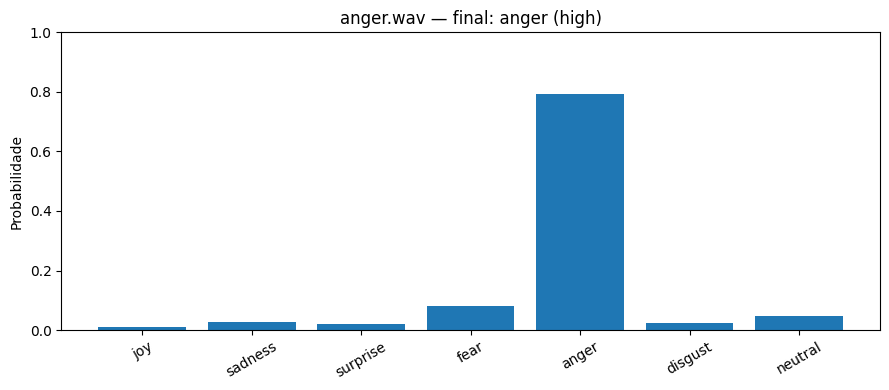

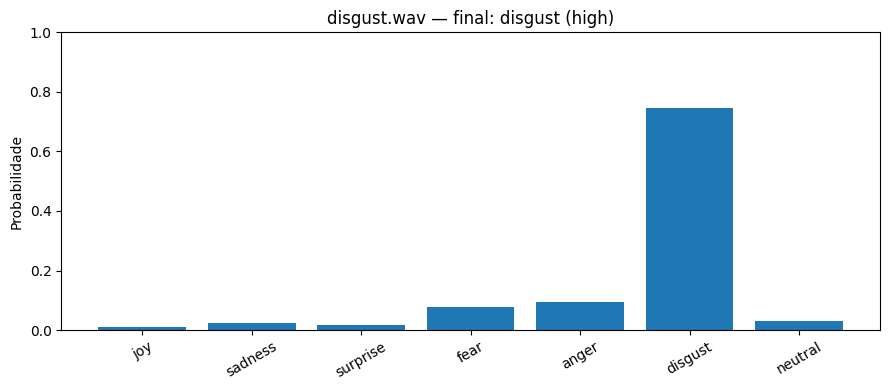

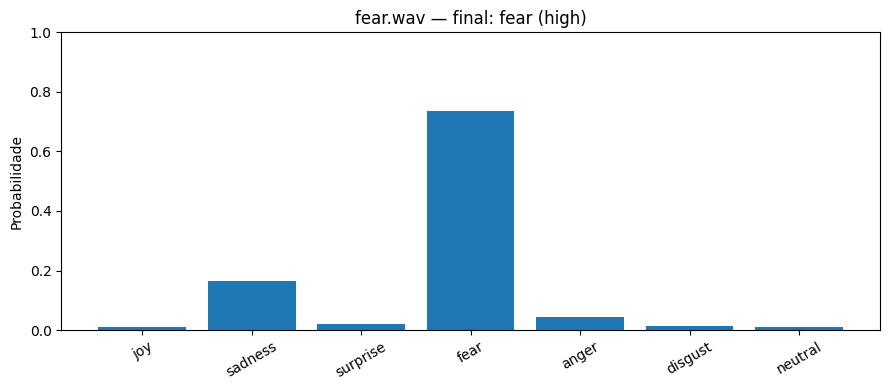

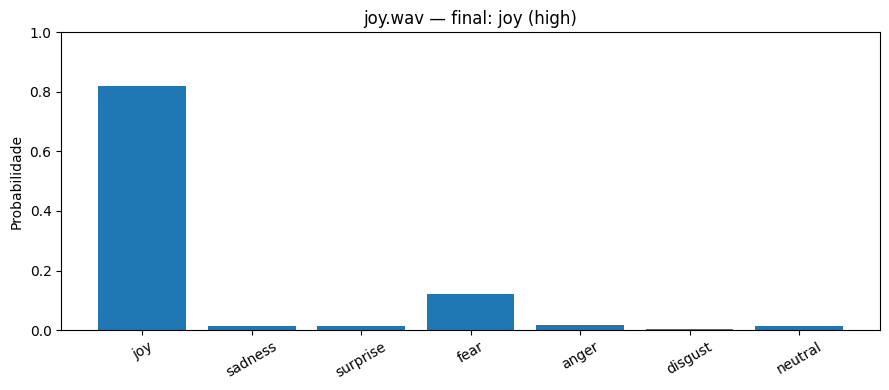

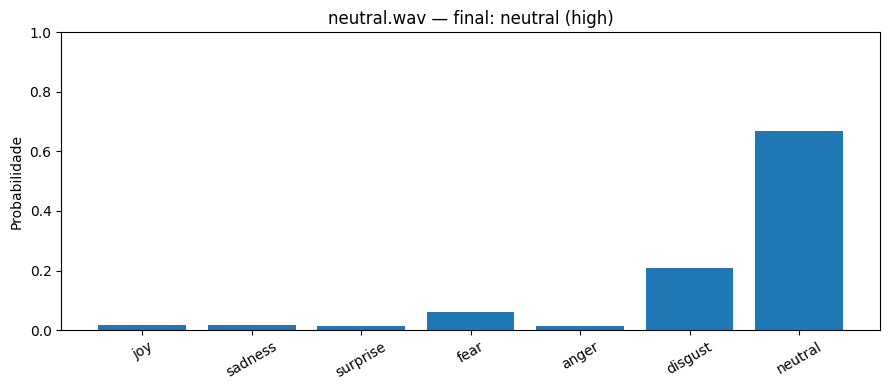

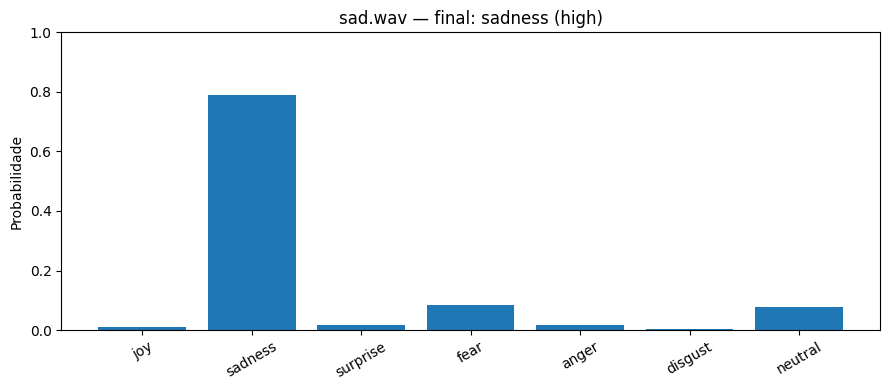

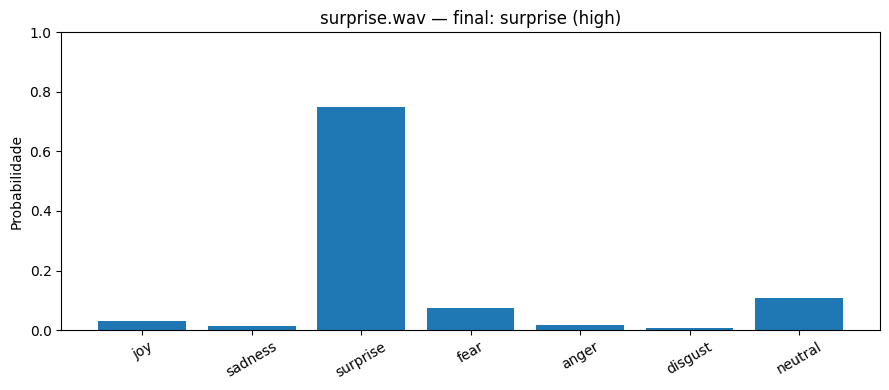

In [14]:
# ============================================================
# 14. Visualizar distribuições finais
# ============================================================


def plot_distribution(dist: Dict[str, float], title: str):
    labels = EMOTIONS
    values = [float(dist.get(e, 0.0)) for e in labels]
    plt.figure(figsize=(9, 4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("Probabilidade")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if "all_results" in globals() and all_results:
    for r in all_results:
        plot_distribution(r["final_distribution"], f"{r['file']} — final: {r['dominant_emotion']} ({r['confidence_level']})")
else:
    print("Sem resultados para visualizar.")


## Interpretação recomendada no relatório

A versão final usa **late fusion adaptativa segura**. O módulo de prosódia continua a ser avançado, combinando features acústicas manuais com embeddings SSL/WavLM, mas é tratado como modalidade complementar porque os testes reais mostraram *domain shift* e possível colapso acústico para uma única emoção.

Justificação:

- o texto continua a ser a modalidade principal, porque a transcrição contém informação semântica direta;
- o classificador textual usa Qwen Advanced_V2 e recebe um pós-processamento semântico conservador para corrigir confusões recorrentes, sobretudo `anger` vs `sadness`, `disgust` vs `anger` e `fear` vs `sadness`;
- a prosódia usa um módulo híbrido mais forte: ramo clássico interpretável + ramo moderno baseado em embeddings de fala pré-treinados;
- como não existe um dataset multimodal emparelhado grande, não se treina stacking, intermediate fusion ou attention-based fusion;
- a fusão limita dinamicamente o peso máximo da prosódia quando há conflito com um texto confiante, baixa confiança acústica ou indícios de colapso no batch;
- a saída final continua a ser uma distribuição completa pelas 7 emoções, com ranking, pesos, incerteza e motivos de proteção usados na fusão.

Formulação curta:

> A arquitetura final usa uma estratégia de late fusion adaptativa segura entre o classificador textual e o classificador acústico. O módulo acústico foi reforçado com embeddings auto-supervisionados de fala, usados como extratores congelados, e combinado com features prosódicas manuais. Contudo, devido ao reduzido número de locutores e ao domain shift observado em gravações reais, a prosódia é usada como sinal complementar e o seu peso é limitado por mecanismos de confiança, conflito intermodal e deteção de colapso. A decisão final resulta da média ponderada das distribuições, preservando uma saída probabilística completa pelas sete emoções.
